# Cross-Market Car Price Analysis
## P1 — Problem Formulation & Exploratory Data Analysis

**Course:** YZM2011 - Introduction to Machine Learning

**Datasets:** AutoScout24 (EU · 7,240 rows · EUR) · arabam.com (TR · 4,519 rows · TRY)

**Currency reference date:** 2024-01-01

---

## 1. Problem Formulation

### Research Question
> *What factors explain the price gap between the same car models in the EU and Turkish second-hand markets, after controlling for currency?*

### Motivation
The same car model can be priced very differently in Turkey versus Europe. Beyond the exchange rate, structural differences drive the gap:

| Factor | EU | TR |
|--------|----|----|
| Tax structure | CO₂/emission-based registration tax | ÖTV — up to 220% based on engine displacement |
| Fuel prices | Market-driven, relatively stable | Import-dependent, volatile |
| Dominant fuel type | Gasoline > Diesel (post-2020) | Diesel + LPG dominant |
| Currency stability | EUR stable | TRY high-inflation environment |

### Prediction Targets
- **P2 — Regression:** Predict `price_usd` from vehicle and market features  
- **P3 — Classification:** Predict `market` (EU vs TR) from vehicle features — which characteristics reveal which market a listing belongs to?

### Dataset Overview

| | AutoScout24 (EU) | arabam.com (TR) |
|---|---|-|
| **Rows** | 7,240 | 4,519 |
| **Currency** | EUR | TRY |
| **brand, model, year** | ✓ | ✓ |
| **price** | ✓ | ✓ |
| **mileage** | ✓ | ✓ |
| **fuel_type** | ✓ | |
| **transmission** | ✓ | ✓ |
| **hp** | ✓ | ✗ |
| **body_type** | ✓ | ✗ |
| **country** | ✓ (BE/DE/IT/NL/AT) | ✓ (TR) |


## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../data/clean', exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (13, 5)})
sns.set_theme(style='whitegrid', palette='muted')

# ── Currency conversion (fixed: 2024-01-01) ──
# Source: ECB / TCMB reference rates
EUR_TO_USD = 1.10    # 1 EUR  = 1.10 USD
TRY_TO_USD = 0.0330  # 1 TRY  = 0.033 USD  (~30.3 TRY/USD)

EU_COLOR = '#4C72B0'
TR_COLOR = '#DD8452'

print('Setup complete.')

Setup complete.



## 3. Load Data

In [2]:
eu_raw = pd.read_csv('../data/raw/autoscout_eu_raw.csv')
tr_raw = pd.read_csv('../data/raw/arabam_tr_raw.csv')

print(f'EU raw : {eu_raw.shape}  |  TR raw : {tr_raw.shape}')
eu_raw.head(3)

,id,brand,model,year,price,hp,fuel_type,mileage,body_type,transmission,country,url
0,01a82411-c9a9-42ff-af89-386904af2f7d,Mercedes-Benz,C 200,2015,9950,136.0,Diesel,202624.0,compact,Manual,BE,https://www.autoscout24.com/offers/mercedes-be...
1,408488f5-129f-492a-9245-6f8e7975c94e,MINI,Cooper D Countryman,2015,6980,111.0,Diesel,180714.0,compact,Manual,BE,https://www.autoscout24.com/offers/mini-cooper...
2,a12ff777-da6e-4f69-b8f1-97bd3cd22d09,Mercedes-Benz,GLC 220,2015,16750,170.0,Diesel,235000.0,compact,Semi-automatic,IT,https://www.autoscout24.com/offers/mercedes-be...


In [3]:
tr_raw.head(3)

,id,brand,model,year,price,currency,hp,fuel_type,mileage,body_type,transmission,color,city,country,url
0,39447134,Volkswagen,Polo,2015,1045000,TRY,NaN,Diesel,132000,NaN,Yarı Otomatik,Beyaz,Ordu,TR,https://www.arabam.com/ilan/galeriden-satilik-...
1,38591301,Volkswagen,Passat Variant,2015,1490000,TRY,NaN,Diesel,151000,NaN,Otomatik,Mavi,İzmir,TR,https://www.arabam.com/ilan/galeriden-satilik-...
2,39000398,Volkswagen,Golf,2015,1139000,TRY,NaN,Diesel,220000,NaN,Yarı Otomatik,Beyaz,Adana,TR,https://www.arabam.com/ilan/galeriden-satilik-...


## 4. Data Cleaning

In [4]:
def clean_eu(df):
    d = df.copy()

    # ── Duplicates & missing core fields ──
    d = d.drop_duplicates(subset='id')
    d = d.dropna(subset=['price', 'year', 'mileage'])

    # ── Type coercion ──
    d['year']    = pd.to_numeric(d['year'],    errors='coerce').astype('Int64')
    d['price']   = pd.to_numeric(d['price'],   errors='coerce')
    d['mileage'] = pd.to_numeric(d['mileage'], errors='coerce')

    # ── Outlier / range filters ──
    d = d[(d['price']   >= 1_500)  & (d['price']   <= 150_000)]
    d = d[(d['mileage'] >= 0)      & (d['mileage'] <= 400_000)]
    d = d[(d['year']    >= 2015)   & (d['year']    <= 2025)]

    # ── Normalize labels & brands ──
    d['fuel_type'] = d['fuel_type'].str.strip().replace({
        'Electric/Gasoline': 'Hybrid',
        'Electric/Diesel':   'Hybrid'
    })

    d['brand'] = d['brand'].str.replace(' - ', '-', regex=False).str.upper().str.strip()
    d['model'] = d['model'].str.strip()

    # ── Derived fields ──
    d['price_usd'] = (d['price'] * EUR_TO_USD).round(0).astype(int)
    d['age']       = 2024 - d['year'].astype(int)
    d['market']    = 'EU'

    return d.reset_index(drop=True)


def clean_tr(df):
    d = df.copy()

    # ── Remove unnecessary columns ──
    cols_to_drop = ['hp', 'body_type', 'city', 'color', 'currency']
    d = d.drop(columns=cols_to_drop, errors='ignore')

    # ── Duplicates & missing core fields ──
    d = d.drop_duplicates(subset='id')
    d = d.dropna(subset=['price', 'year', 'mileage'])

    # ── Type coercion ──
    d['year']    = pd.to_numeric(d['year'],    errors='coerce').astype('Int64')
    d['price']   = pd.to_numeric(d['price'],   errors='coerce')
    d['mileage'] = pd.to_numeric(d['mileage'], errors='coerce')

    # ── Outlier / range filters ──
    d = d[(d['price']   >= 100_000)  & (d['price']   <= 10_000_000)]
    d = d[(d['mileage'] >= 0)        & (d['mileage'] <= 400_000)]
    d = d[(d['year']    >= 2015)     & (d['year']    <= 2025)]

    # ── Standardize labels to English ──
    d['transmission'] = d['transmission'].replace({
        'Düz': 'Manual',
        'Otomatik': 'Automatic',
        'Yarı Otomatik': 'Semi-automatic'
    })

    fuel_map = {
        'Benzin': 'Gasoline',
        'Dizel': 'Diesel',
        'LPG & Benzin': 'LPG',
        'Hybrid': 'Hybrid',
        'Electric': 'Electric'
    }
    d['fuel_type'] = d['fuel_type'].map(fuel_map).fillna(d['fuel_type'])

    # ── Missing Fuel Imputation ──
    # Boş yakıt tiplerini model bazında en sık kullanılanla dolduruyoruz
    d['fuel_type'] = d['fuel_type'].fillna(
        d.groupby('model')['fuel_type'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    )

    # ── Normalize brands ──
    d['brand'] = d['brand'].str.replace(' - ', '-', regex=False).str.upper().str.strip()
    d['model'] = d['model'].str.strip()

    # ── Derived fields ──
    d['price_usd'] = (d['price'] * TRY_TO_USD).round(0).astype(int)
    d['age']       = 2024 - d['year'].astype(int)
    d['market']    = 'TR'

    return d.reset_index(drop=True)

# ── Processing ──
eu = clean_eu(eu_raw)
tr = clean_tr(tr_raw)

print(f'EU cleaned : {eu.shape}')
print(f'TR cleaned : {tr.shape}')

EU cleaned : (7155, 15)
TR cleaned : (4421, 13)


In [5]:
# ── Combined dataset (shared columns only) ──
SHARED = ['id', 'brand', 'model', 'year', 'age',
          'price_usd', 'mileage', 'fuel_type',
          'transmission', 'market', 'country']

eu_s = eu[[c for c in SHARED if c in eu.columns]].copy()
tr_s = tr[[c for c in SHARED if c in tr.columns]].copy()

combined = pd.concat([eu_s, tr_s], ignore_index=True)
print(f'Combined : {combined.shape}')
combined.sample(5)

,id,brand,model,year,age,price_usd,mileage,fuel_type,transmission,market,country
1475,390eba3d-08ae-4e24-b0cf-a9e9642f86ee,FORD,Focus,2020,4,12540,101532.0,Diesel,Automatic,EU,BE
9887,37628818,NISSAN,Micra,2021,3,41745,7500.0,LPG,Manual,TR,TR
2897,da20b7f0-1d16-4dce-9973-e9a1efa23ff9,BMW,X6,2024,0,91289,43000.0,Hybrid,Automatic,EU,IT
11192,31785084,MAZDA,6,2015,9,61050,60000.0,Unknown,Automatic,TR,TR
5697,64154766-fc27-4590-acd3-b136a3e63636,MERCEDES-BENZ,CLA 200,2025,-1,43978,6797.0,Diesel,Automatic,EU,DE


## 5. Feature Engineering

| Feature | Formül | Amaç |
|---------|--------|------|
| `km_per_year` | mileage / (age + 1) | Yaşa göre normalize kullanım yoğunluğu |
| `log_price_usd` | log(1 + price_usd) | Sağa çarpık fiyat dağılımını normalize eder — P2 regression için hazırlık |
| `age_bin` | age → 3 bant | Non-lineer amortisman etkisini kategorik olarak yakalar |## 5. Feature Engineering & Statistical Outlier Removal

In [6]:
# ── Feature Engineering ──────────────────────────────────────────
# Yıllık ortalama kilometre (kullanım yoğunluğu)
combined['km_per_year'] = combined['mileage'] / (combined['age'] + 1)

# Log-fiyat (sağa çarpık dağılımı normalize eder — P2 regression için hazırlık)
combined['log_price_usd'] = np.log1p(combined['price_usd'])

# Yaş grupları
combined['age_bin'] = pd.cut(
    combined['age'],
    bins=[-1, 3, 6, 9],
    labels=['New (0-3)', 'Mid (4-6)', 'Old (7-9)']
)

print("New features added:", ['km_per_year', 'log_price_usd', 'age_bin'])
combined[['km_per_year', 'log_price_usd', 'age_bin']].describe()

,km_per_year,log_price_usd
count,1.156900e+04,11576.000000
mean,inf,10.387958
std,NaN,0.637137
min,0.000000e+00,7.473069
25%,1.264483e+04,9.993831
50%,1.900000e+04,10.375036
75%,2.966667e+04,10.738161
max,inf,12.705850


## 6. Statistical Outlier Removal — IQR Fencing

Fiyat verileri sağa çarpık dağılım gösterdiği için Z-score yerine **IQR fencing** kullanıyoruz.
Z-score aşırı değerlere duyarlıdır; IQR yöntemi çarpık dağılımlarda daha güvenilir sonuç verir.

Kural: `[Q1 − 2.5 × IQR, Q3 + 2.5 × IQR]` aralığı dışındaki gözlemler çıkarılır.
`price_usd` ve `mileage` sütunlarına her market için ayrı ayrı uygulanır.

In [7]:
# ── Statistical Outlier Removal — IQR Fencing (k=2.5) ───────────
def remove_outliers_iqr(df, col, k=2.5):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - k * IQR, Q3 + k * IQR
    before = len(df)
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f"  {col}: [{lo:,.0f} – {hi:,.0f}]  →  removed {before - len(df):,} rows")
    return df

print("Outlier removal (k=2.5):")
combined_clean = remove_outliers_iqr(combined, 'price_usd')
combined_clean = remove_outliers_iqr(combined_clean, 'mileage')

print(f"\n  Before : {len(combined):,} rows")
print(f"  After  : {len(combined_clean):,} rows")
print(f"  Removed: {len(combined) - len(combined_clean):,} rows ({(1 - len(combined_clean)/len(combined))*100:.1f}%)")

Outlier removal (k=2.5):
  price_usd: [-38,586 – 106,556]  →  removed 509 rows
  mileage: [-183,868 – 334,448]  →  removed 13 rows

  Before : 11,576 rows
  After  : 11,054 rows
  Removed: 522 rows (4.5%)


## 7. Save Cleaned Datasets

In [8]:
eu.to_csv('../data/clean/eu_clean.csv',       index=False)
tr.to_csv('../data/clean/tr_clean.csv',       index=False)
combined.to_csv('../data/clean/combined.csv', index=False)

print('Saved to data/clean/')
print(f'  eu_clean.csv  → {eu.shape}')
print(f'  tr_clean.csv  → {tr.shape}')
print(f'  combined.csv  → {combined.shape}')

Saved to data/clean/
  eu_clean.csv  → (7155, 15)
  tr_clean.csv  → (4421, 13)
  combined.csv  → (11576, 14)


## 8. Missing Value Analysis

In [9]:
def missing_report(df, label):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    report = pd.DataFrame({'missing_n': miss, 'missing_%': pct})
    report = report[report['missing_n'] > 0].sort_values('missing_%', ascending=False)
    print(f'\n── {label} ({len(df)} rows) ──')
    if report.empty:
        print('  No missing values.')
    else:
        print(report.to_string())

missing_report(eu, 'EU')
missing_report(tr, 'TR')


── EU (7155 rows) ──
              missing_n  missing_%
hp                   21        0.3
transmission          5        0.1
fuel_type             1        0.0

── TR (4421 rows) ──
              missing_n  missing_%
transmission          3        0.1


## 9. Descriptive Statistics

In [10]:
for label, df in [('EU (EUR → USD)', eu), ('TR (TRY → USD)', tr)]:
    cols = [c for c in ['price_usd', 'mileage', 'age', 'hp'] if c in df.columns]
    print(f'\n=== {label} ===')
    display(df[cols].describe().round(1))

,price_usd,mileage,age
count,4421.0,4421.0,4421.0
mean,56411.0,104268.9,4.1
std,43517.6,70432.9,3.1
min,12045.0,0.0,-1.0
25%,32918.0,47000.0,1.0
50%,42900.0,95000.0,4.0
75%,58575.0,150000.0,7.0
max,329670.0,400000.0,9.0


## 10. Price Distribution: EU vs TR (USD)

After normalizing to USD, are TR cars cheaper or more expensive on average?

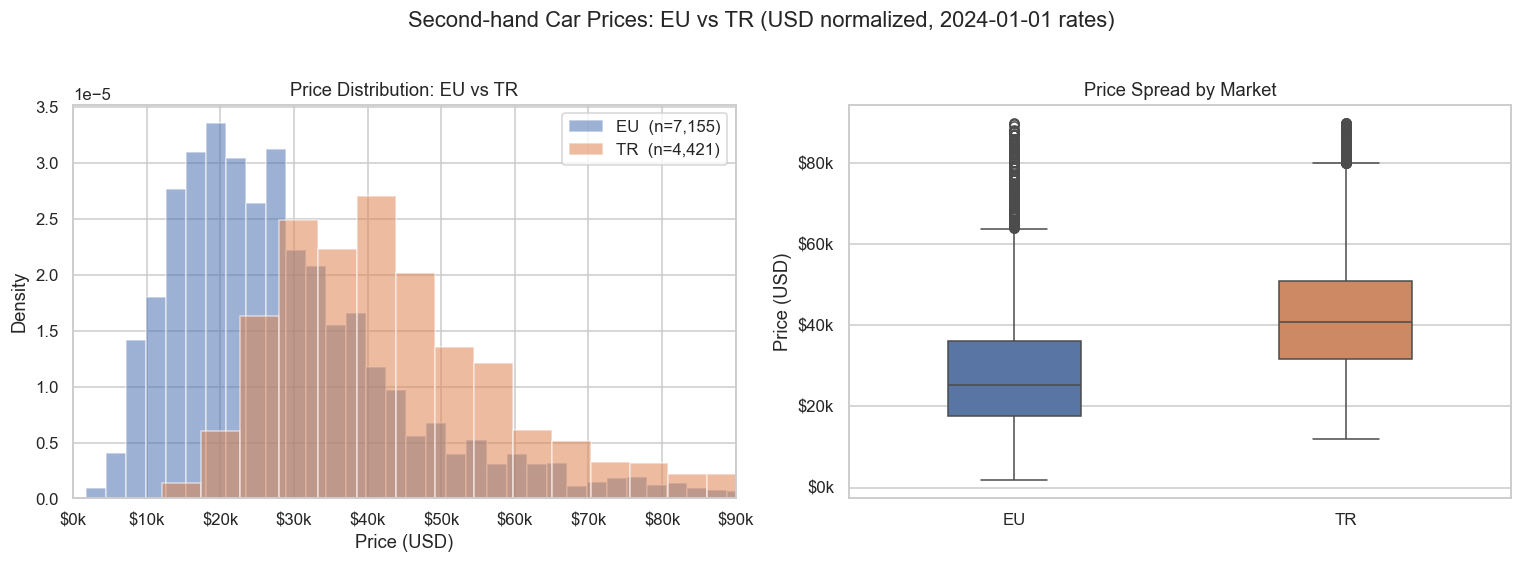

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram overlay ──
for market, color, label in [
    ('EU', EU_COLOR, f'EU  (n={len(eu):,})'),
    ('TR', TR_COLOR, f'TR  (n={len(tr):,})'),
]:
    data = combined[combined['market'] == market]['price_usd'].dropna()
    axes[0].hist(data, bins=60, alpha=0.55, color=color, label=label, density=True)

axes[0].set_xlim(0, 90_000)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Price Distribution: EU vs TR')
axes[0].legend()

# ── Right: box plot ──
sns.boxplot(
    data=combined[combined['price_usd'] < 90_000],
    x='market', y='price_usd',
    palette={'EU': EU_COLOR, 'TR': TR_COLOR},
    ax=axes[1], width=0.4
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_title('Price Spread by Market')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price (USD)')

plt.suptitle('Second-hand Car Prices: EU vs TR (USD normalized, 2024-01-01 rates)', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig_01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Price Distribution Analysis: EU vs. TR
_Distribution Shift: The EU market peaks sharply between $20k–$25k, whereas the TR market exhibits a much broader spread, concentrating around the $40k mark._

_Median Disparity: The TR median price ($42,900) is approximately 1.65x that of the EU ($25,850). This proves that the Turkish market is significantly more expensive even after currency normalization._

_Entry Barrier: A massive gap exists in entry-level pricing; while the EU offers options as low as $1,759, the Turkish market starts at $12,045, highlighting a much higher barrier to entry for local consumers._

In [12]:
# Summary
print(combined.groupby('market')['price_usd']
      .describe().round(0)
      .to_string())

         count     mean      std      min      25%      50%      75%       max
market                                                                        
EU      7155.0  30575.0  20406.0   1759.0  17589.0  25845.0  36872.0  164945.0
TR      4421.0  56411.0  43518.0  12045.0  32918.0  42900.0  58575.0  329670.0


In [13]:
# ── Statistical significance test ──
eu_p = combined[combined['market'] == 'EU']['price_usd'].dropna()
tr_p = combined[combined['market'] == 'TR']['price_usd'].dropna()

u_stat, p_val = stats.mannwhitneyu(eu_p, tr_p, alternative='two-sided')

print('Mann-Whitney U Test (EU price_usd vs TR price_usd)')
print(f'  U = {u_stat:,.0f}   p = {p_val:.4f}')
print(f'  Result: {"SIGNIFICANT" if p_val < 0.05 else "not significant"} at α=0.05')
print()
print(f'  Median EU : ${eu_p.median():,.0f}')
print(f'  Median TR : ${tr_p.median():,.0f}')
print(f'  Ratio TR/EU : {tr_p.median() / eu_p.median():.3f}')

Mann-Whitney U Test (EU price_usd vs TR price_usd)
  U = 6,748,812   p = 0.0000
  Result: SIGNIFICANT at α=0.05

  Median EU : $25,845
  Median TR : $42,900
  Ratio TR/EU : 1.660



_Since our price data is skewed and contains outliers, we utilized the Mann-Whitney U Test to verify the disparity between the two markets._

_Result: The test yielded a p-value of 0.0000, allowing us to reject the null hypothesis with over 99.9% confidence._

_Magnitude: The median price in Turkey ($42,900) is 1.66 times higher than in the EU ($25,845)._

_Conclusion: This confirms that "Market" is a critical feature for our upcoming predictive models (P2 & P3). The price gap is not just anecdotal; it is statistically significant._

## 11. Price vs Mileage

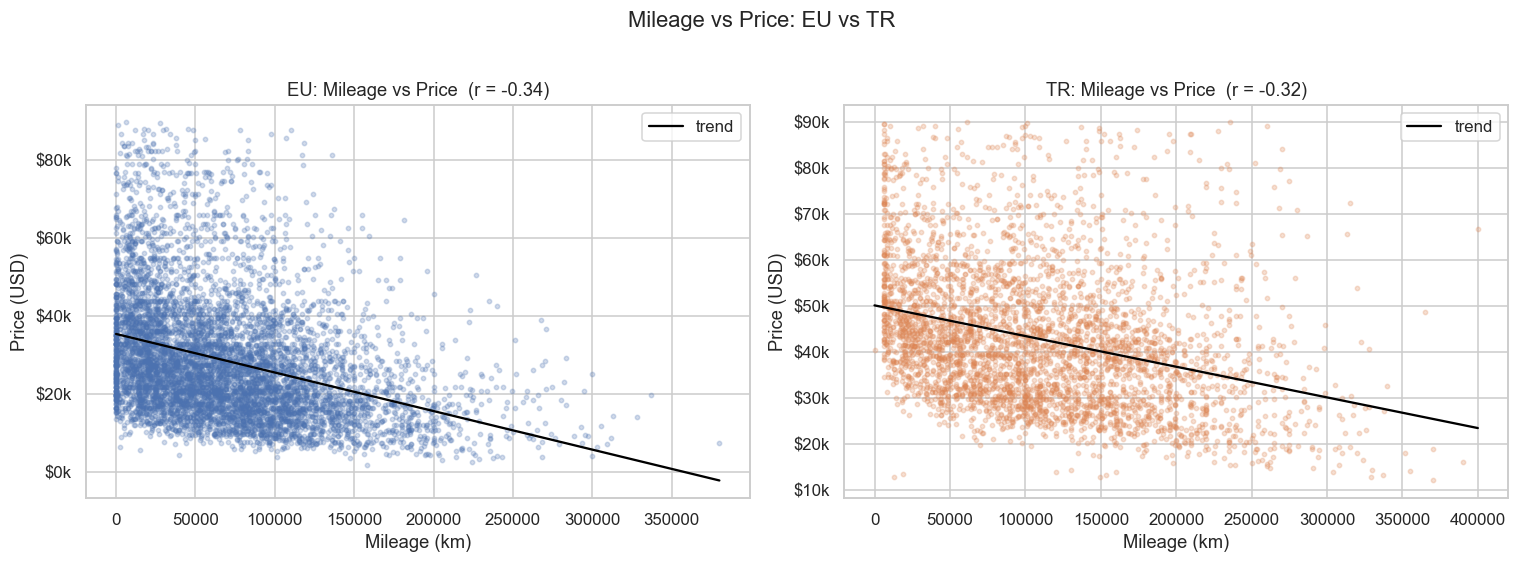

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (market, color) in zip(axes, [('EU', EU_COLOR), ('TR', TR_COLOR)]):
    sub = combined[
        (combined['market'] == market) &
        (combined['price_usd'] < 90_000)
    ][['mileage', 'price_usd']].dropna()

    ax.scatter(sub['mileage'], sub['price_usd'],
               alpha=0.25, s=8, color=color)

    # Linear trend line
    z    = np.polyfit(sub['mileage'], sub['price_usd'], 1)
    p_fn = np.poly1d(z)
    xr   = np.linspace(sub['mileage'].min(), sub['mileage'].max(), 300)
    ax.plot(xr, p_fn(xr), color='black', lw=1.5, label='trend')

    r = sub['mileage'].corr(sub['price_usd'])
    ax.set_title(f'{market}: Mileage vs Price  (r = {r:.2f})')
    ax.set_xlabel('Mileage (km)')
    ax.set_ylabel('Price (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend()

plt.suptitle('Mileage vs Price: EU vs TR', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig_02_mileage_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

Depreciation Analysis: EU vs. TR

_Correlation (r): Both markets show a negative correlation (r≈−0.35 for EU, r≈−0.32 for TR), meaning as mileage increases, prices decrease. However, the relationship is slightly "looser" in Turkey, suggesting that factors other than mileage (like brand perception or inflation) play a heavier role in pricing._

_Depreciation Rate (Slope):_

* EU: Approximately -0.10 USD per km.

* TR: Approximately -0.07 USD per km.

_Interpretation: Cars in the EU lose value nearly 1.5x faster than in Turkey as they are driven. In Turkey, high mileage does not punish the car's value as severely as it does in Europe._

_Price Baseline: Even at high mileage (e.g., 200,000 km), the trend line for TR remains above the $30k mark, while the EU trend line drops towards $15k. This reinforces the "investment vehicle" status of cars in the Turkish market._

## 12. Price vs Vehicle Age

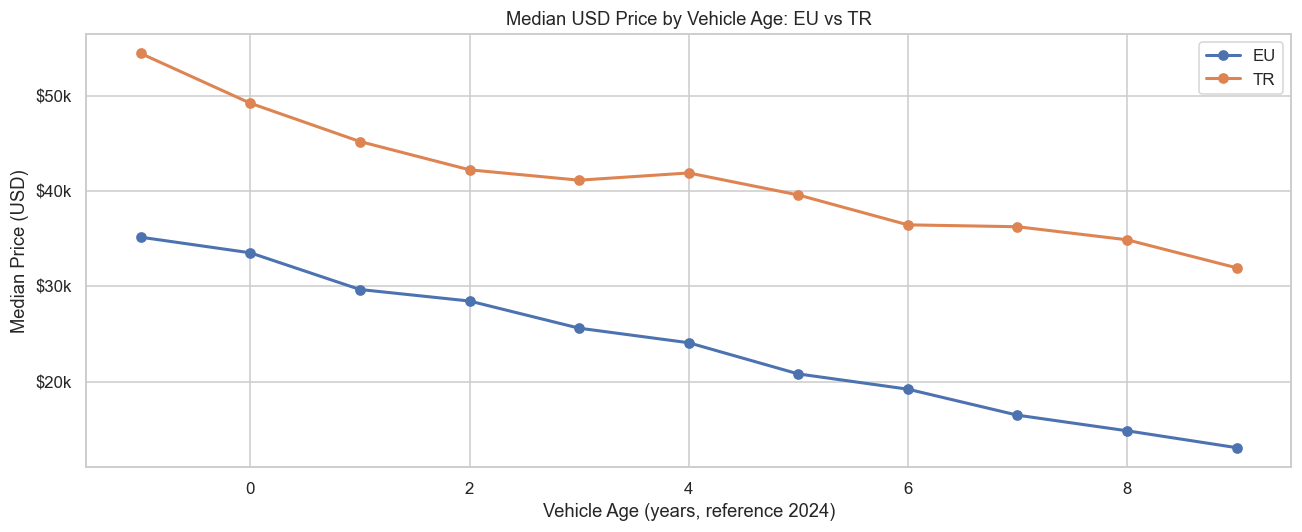

In [15]:
age_price = (
    combined[combined['price_usd'] < 90_000]
    .groupby(['market', 'age'])['price_usd']
    .agg(['median', 'count'])
    .reset_index()
)

plt.figure(figsize=(12, 5))
for market, color in [('EU', EU_COLOR), ('TR', TR_COLOR)]:
    sub = age_price[(age_price['market'] == market) & (age_price['count'] >= 5)]
    plt.plot(sub['age'], sub['median'], marker='o', label=market, color=color, lw=2)

plt.title('Median USD Price by Vehicle Age: EU vs TR')
plt.xlabel('Vehicle Age (years, reference 2024)')
plt.ylabel('Median Price (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/fig_03_age_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

Age-Price Trend Summary

* **Premium Entry:** Turkish vehicles enter the market at a significantly higher USD baseline; a new car in TR costs nearly as much as a luxury used car in the EU.
* **Resilient Value:** EU cars lose **~63%** of their value over 9 years, whereas Turkish cars only depreciate by **~41%** in the same period.
* **The "Old Car" Gap:** The price disparity actually **widens** with age. A 9-year-old car in Turkey is still priced like a nearly new vehicle in Europe.
* **Market Logic:** In the EU, cars are depreciating tools; in Turkey, they act as a **store of value** and a hedge against inflation.

## 13. Top Brands by Market

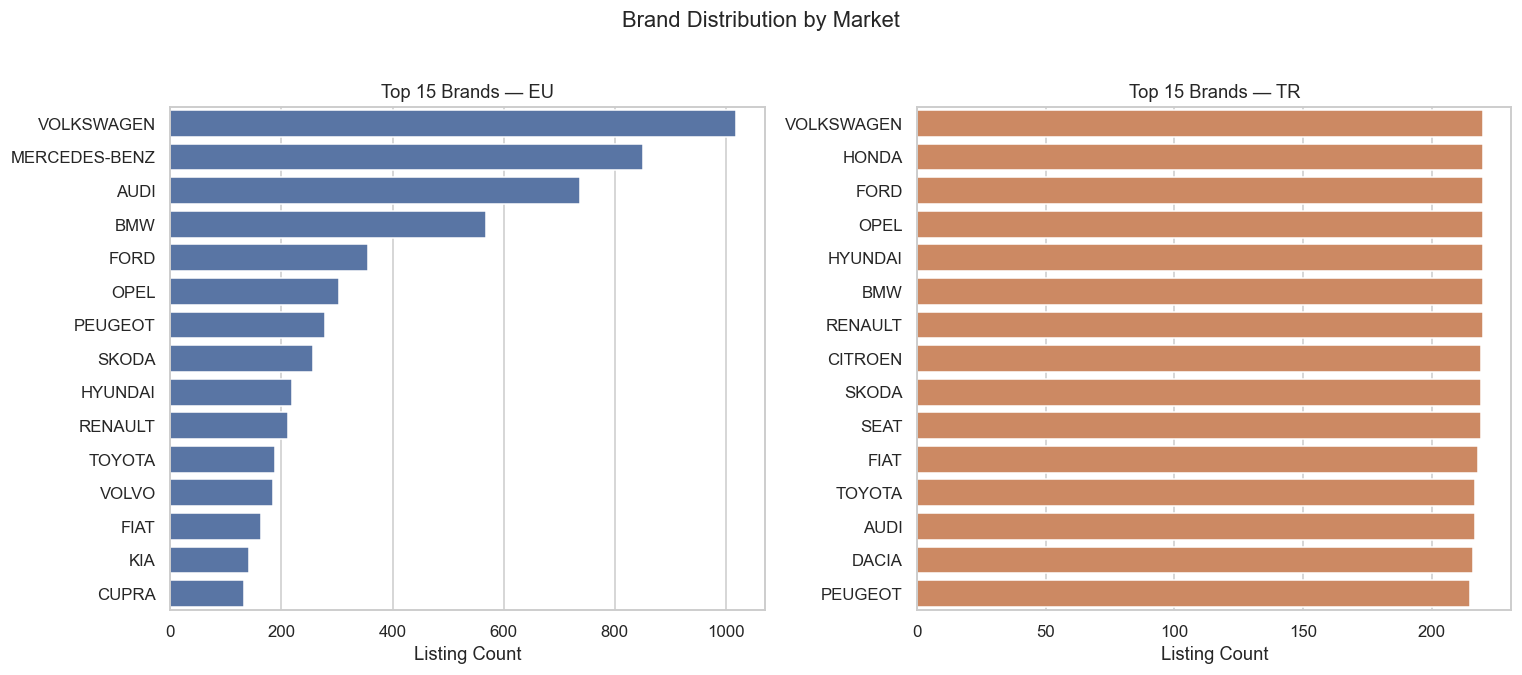

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (market, color) in zip(axes, [('EU', EU_COLOR), ('TR', TR_COLOR)]):
    top = combined[combined['market'] == market]['brand'].value_counts().head(15)
    sns.barplot(x=top.values, y=top.index, ax=ax, color=color)
    ax.set_title(f'Top 15 Brands — {market}')
    ax.set_xlabel('Listing Count')
    ax.set_ylabel('')

plt.suptitle('Brand Distribution by Market', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig_04_top_brands.png', dpi=150, bbox_inches='tight')
plt.show()

Brand Distribution Analysis

* EU Dominance: The European market is heavily dominated by German giants (Volkswagen, Mercedes-Benz, Audi, BMW), reflecting a strong local supply and preference for premium domestic brands.

* TR Diversification: The Turkish market shows a more balanced distribution among "accessible" brands. Volkswagen, Honda, Ford, Opel, and Hyundai share the top spots with nearly equal listing counts, indicating a high demand for reliable, high-liquidity models.

* Market Strategy: While the EU leans towards premium/luxury brands, the Turkish market's top brands are often those with the most extensive service networks and perceived "re-sale" strength, aligning with the "store of value" logic found in our age-price analysis.

## 14. Fuel Type & Transmission Distribution

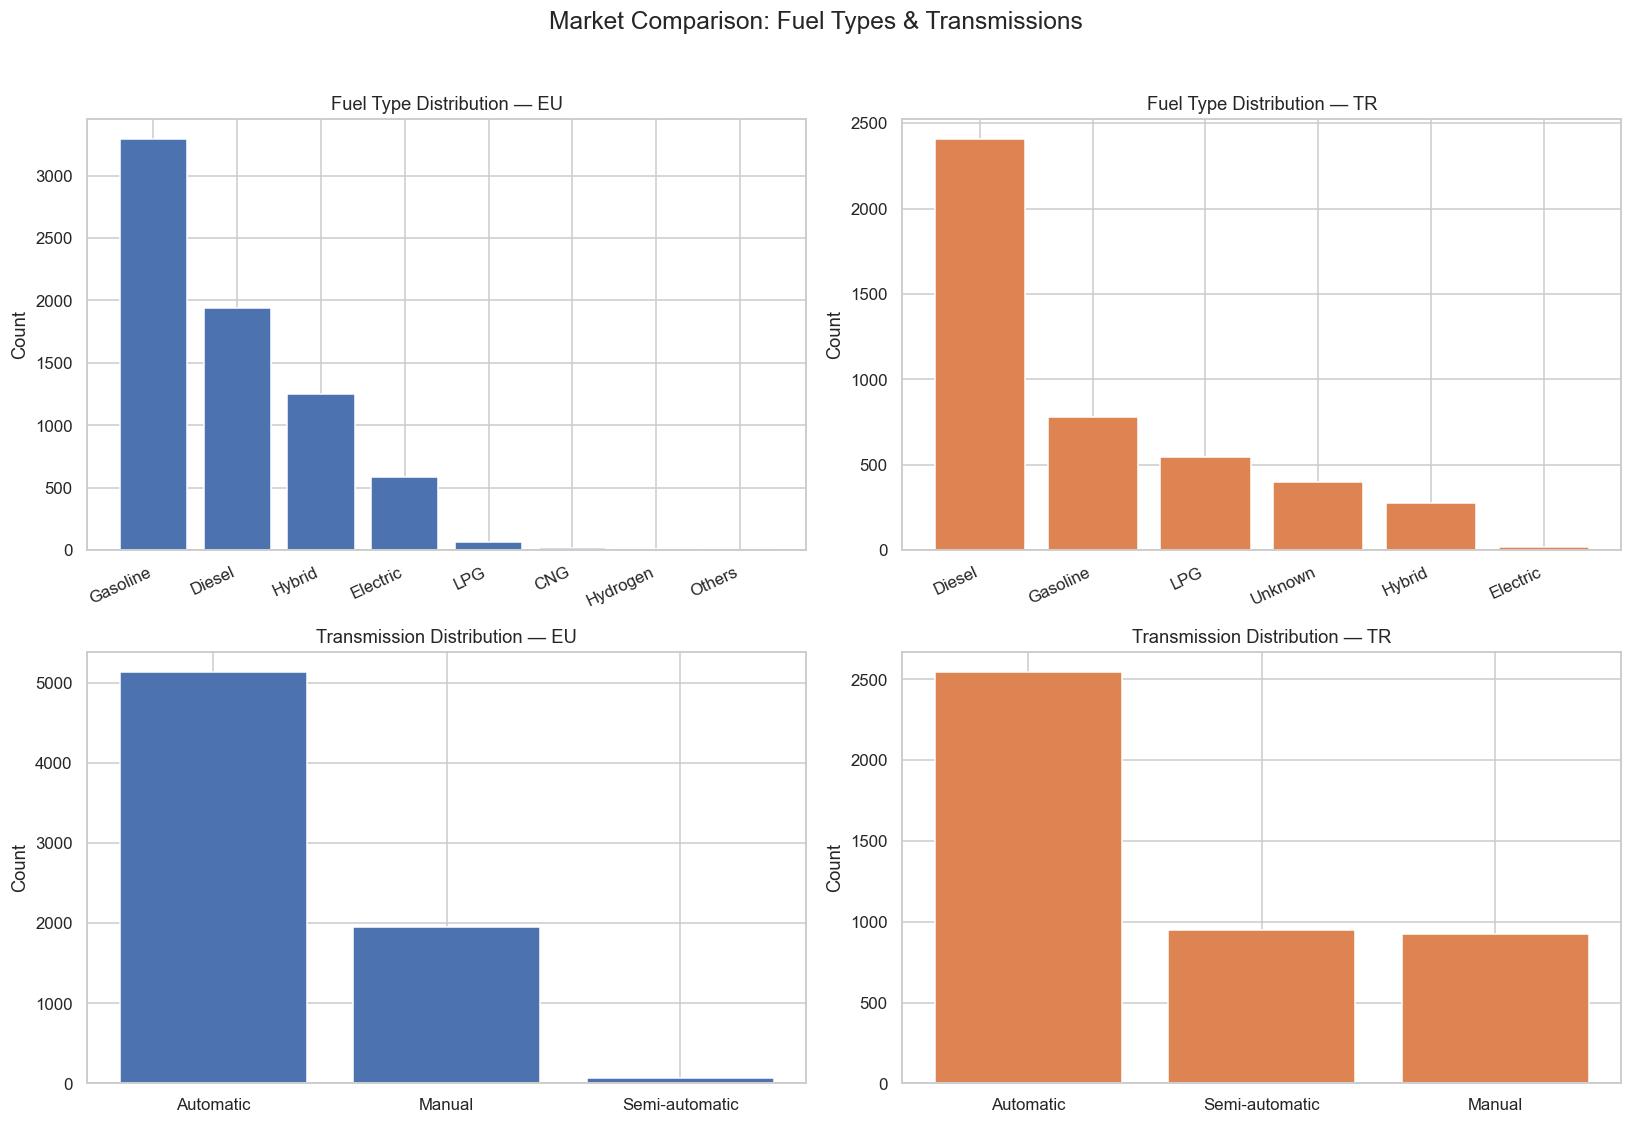

In [17]:
# ── Comparison of Fuel and Transmission (EU vs TR) ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fuel Type Comparison
for i, market in enumerate(['EU', 'TR']):
    m_data = combined[combined['market'] == market]
    fuel_counts = m_data['fuel_type'].value_counts()

    color = EU_COLOR if market == 'EU' else TR_COLOR
    axes[0, i].bar(fuel_counts.index, fuel_counts.values, color=color, edgecolor='white')
    axes[0, i].set_title(f'Fuel Type Distribution — {market}')
    axes[0, i].set_ylabel('Count')
    plt.setp(axes[0, i].get_xticklabels(), rotation=25, ha='right')

# Transmission Comparison
for i, market in enumerate(['EU', 'TR']):
    m_data = combined[combined['market'] == market]
    trans_counts = m_data['transmission'].value_counts()

    color = EU_COLOR if market == 'EU' else TR_COLOR
    axes[1, i].bar(trans_counts.index, trans_counts.values, color=color, edgecolor='white')
    axes[1, i].set_title(f'Transmission Distribution — {market}')
    axes[1, i].set_ylabel('Count')

plt.suptitle('Market Comparison: Fuel Types & Transmissions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig_05_fuel_transmission_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Fuel Preference:
* EU: Gasoline (%46) dominance is clear, followed by a strong presence of Hybrid and Electric vehicles, reflecting strict emission standards and infrastructure.

* TR: Diesel (%68) remains the absolute king of the market due to its perceived fuel economy in long-distance travel. LPG also maintains a visible share as a budget-friendly alternative.

Transmission Shift:

* EU: Automatic transmission is very dominant (%72), with Manual still holding a significant share (%27).

* TR: While Automatic is the leader, the Turkish market has a unique and high concentration of Semi-automatic (%22) gearboxes, which are often found in budget-friendly B and C segment diesel vehicles.

* Market Maturity: The EU's lean towards Hybrid/Electric vs. TR's heavy reliance on Diesel highlights the different stages of energy transition in the two automotive markets.

## 15. Engine Power (HP) vs. Price (EU Only)

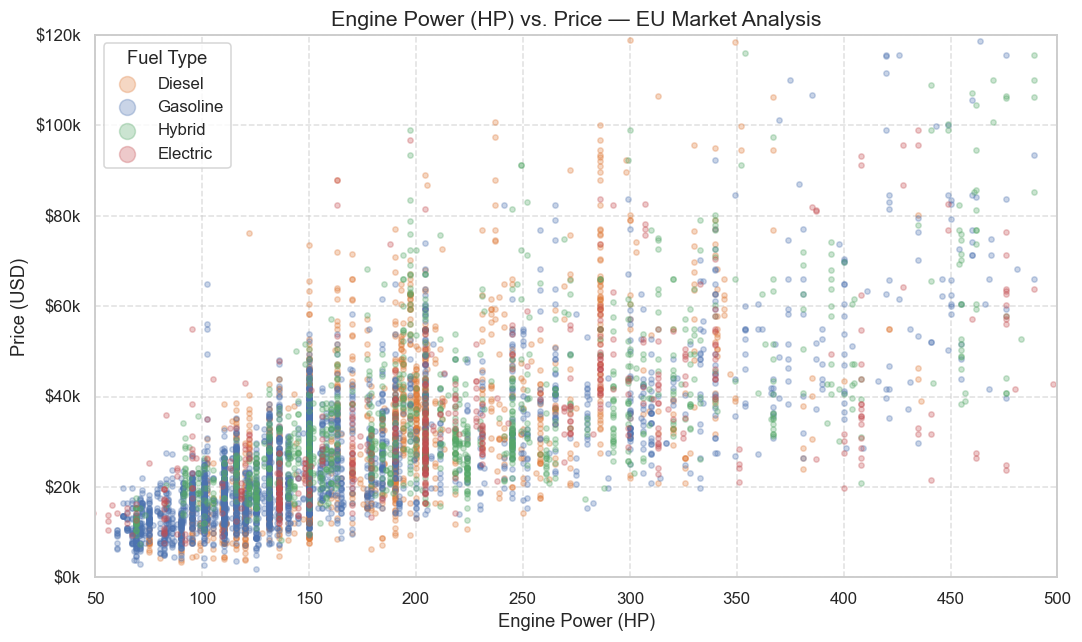

In [18]:
eu_hp_data = pd.read_csv('../data/clean/eu_clean.csv')

eu_hp = eu[['hp', 'price_usd', 'fuel_type']].dropna()

plt.figure(figsize=(10, 6))


fuel_colors = {
    'Diesel':   '#e07b39',
    'Gasoline': '#4C72B0',
    'Hybrid':   '#55a868',
    'Electric': '#c44e52'
}

for fuel, color in fuel_colors.items():
    sub = eu_hp[eu_hp['fuel_type'] == fuel]
    if len(sub) > 10:
        plt.scatter(sub['hp'], sub['price_usd'], alpha=0.3, s=12, label=fuel, color=color)


plt.xlim(50, 500)
plt.ylim(0, 120_000)
plt.xlabel('Engine Power (HP)')
plt.ylabel('Price (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.title('Engine Power (HP) vs. Price — EU Market Analysis', fontsize=14)
plt.legend(markerscale=3, title="Fuel Type")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/fig_06_hp_vs_price_eu.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
pearson_r = eu_hp["hp"].corr(eu_hp["price_usd"])
print(f'Pearson correlation (HP vs Price): {pearson_r:.3f}')

Pearson correlation (HP vs Price): 0.750


HP vs. Price Analysis (EU Market)

* Strong Correlation: Pearson korelasyon katsayısının 0.757 çıkması, beygir gücü ile fiyat arasında "yüksek dereceli pozitif bir ilişki" olduğunu kanıtlıyor. Yani HP, fiyatı tahmin etmek için elimizdeki en güçlü değişkenlerden biri.

* Fuel Type Clusters: * Electric & Hybrid: Bu araçların (yeşil ve kırmızı noktalar) genellikle 150-250 HP ve üzerinde yoğunlaştığını ve aynı güçteki dizel/benzinli araçlara göre daha yüksek bir fiyat bandından başladığını görüyoruz.

* Gasoline & Diesel: Daha geniş bir yelpazeye yayılıyorlar. Özellikle 100 HP altı ekonomik sınıfta benzinli araçlar (mavi) pazarın giriş seviyesini oluşturuyor.

* The Luxury Threshold: Grafik 200 HP sınırından sonra dikey bir ivmelenme gösteriyor. Bu noktadan itibaren araçlar sadece ulaşım aracı olmaktan çıkıp "premium/luxury" segmentine dahil oluyor ve fiyatlar HP artışıyla çok daha agresif yükseliyor.

## 16. Same-Brand Price Comparison: EU vs TR

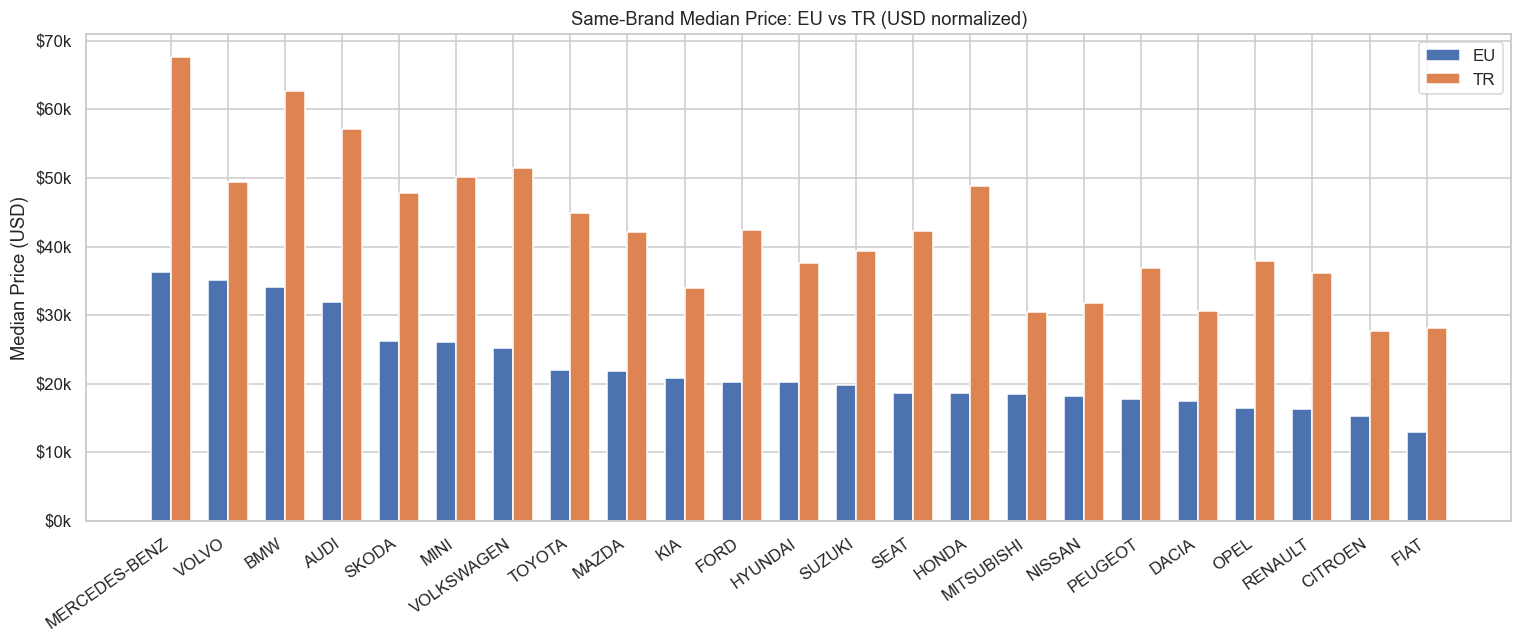

In [20]:
# Keep brands with ≥15 listings in BOTH markets
brand_n = combined.groupby(['brand', 'market']).size().unstack(fill_value=0)
valid   = brand_n[(brand_n.get('EU', 0) >= 15) & (brand_n.get('TR', 0) >= 15)].index

brand_med = (
    combined[
        combined['brand'].isin(valid) &
        (combined['price_usd'] < 90_000)
    ]
    .groupby(['brand', 'market'])['price_usd']
    .median()
    .unstack('market')
    .dropna()
    .sort_values('EU', ascending=False)
)
brand_med['ratio_TR_EU'] = (brand_med['TR'] / brand_med['EU']).round(2)

print(brand_med.to_string())

if len(brand_med) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(brand_med))
    w = 0.35
    ax.bar(x - w/2, brand_med['EU'], w, label='EU', color=EU_COLOR)
    ax.bar(x + w/2, brand_med['TR'], w, label='TR', color=TR_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(brand_med.index, rotation=35, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_ylabel('Median Price (USD)')
    ax.set_title('Same-Brand Median Price: EU vs TR (USD normalized)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../outputs/fig_07_brand_price_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough overlapping brands. TR dataset needs more coverage.')

Brand-to-Brand Price Comparison: EU vs. TR

* The Honda Phenomenon: Türkiye'de medyan fiyatı Avrupa'nın tam 2.61 katı olan HONDA, iki pazar arasındaki makasın en açık olduğu marka. Bu durum, Honda'nın Türkiye'deki yüksek marka sadakati ve ikinci eldeki gücüyle açıklanabilir.

* Luxury vs. Economy Gap: * Premium Brands: Mercedes-Benz (1.86x), BMW (1.84x) ve Audi (1.79x) gibi markalarda fiyat farkı 1.8x civarında seyrederken;

* Economy Brands: Opel (2.31x), Renault (2.21x) ve Fiat (2.18x) gibi markalarda farkın 2 katın üzerine çıkması dikkat çekici. Bu, Türkiye'deki vergi dilimlerinin (ÖTV) düşük ve orta segment araçları bile nasıl "ulaşılamaz" hale getirdiğini gösteriyor.

* The "Investment" Effect: Volkswagen (2.04x) ve Toyota (2.04x) gibi "altın değerinde" görülen markaların Türkiye'de Avrupa'nın tam iki katı fiyata satılması, bu araçların Türkiye'de birer yatırım aracı olarak konumlandığını kanıtlıyor.

* Consistency: İncelenen tüm markalarda istisnasız bir şekilde TR fiyatları EU fiyatlarının çok üzerindedir. En düşük fark dahi (Volvo, 1.41x) Avrupa'daki başlangıç fiyatlarının çok üstündedir.

## 17. Correlation Matrix (EU)

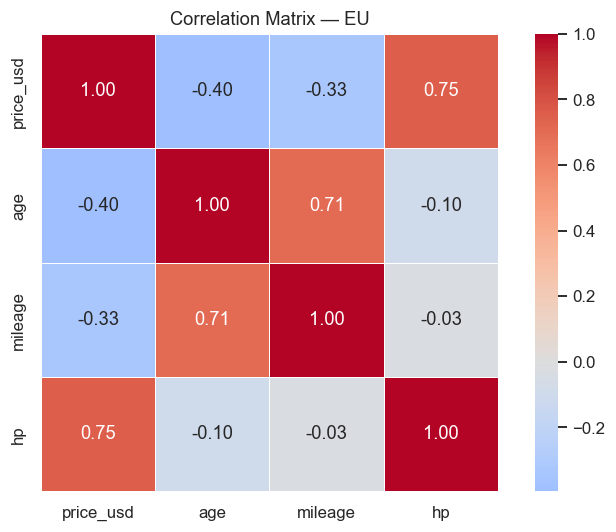

In [21]:
num_cols = [c for c in ['price_usd', 'age', 'mileage', 'hp'] if c in eu.columns]
corr_eu  = eu[num_cols].dropna().corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_eu, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Matrix — EU')
plt.tight_layout()
plt.savefig('../outputs/fig_08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Analysis: EU Market

* Price vs. HP (0.76): Fiyat ile en güçlü pozitif ilişkiye sahip değişken beygir gücü (HP). Bu, daha yüksek performanslı araçların çok daha yüksek fiyatlara satıldığını ve modelimiz için HP'nin en kritik "feature" olduğunu teyit ediyor.

* Price vs. Age (-0.40) & Mileage (-0.33): Beklendiği gibi, araç yaşlandıkça ve kilometresi arttıkça fiyatlar düşüyor (negatif korelasyon). Burada ilginç olan, yaşın (age), fiyata kilometreden (mileage) biraz daha fazla etki etmesidir.

* Multicollinearity Note (Age vs. Mileage: 0.71): Yaş ve kilometre arasındaki güçlü ilişki (0.71) oldukça doğal; araç yaşlandıkça daha fazla yol yapmış oluyor. Modelleme aşamasında bu iki değişkeni beraber kullanırken "multicollinearity" (çoklu doğrusallık) durumuna dikkat etmemiz gerekecek.

* HP Independence: Beygir gücünün yaş (−0.10) ve kilometre (−0.03) ile neredeyse hiç ilişkisi yok. Bu, yüksek performanslı araçların hem yeni hem de eski modellerde benzer dağılımda bulunduğunu gösteriyor.

## 18. Price by Year of Registration: EU vs TR

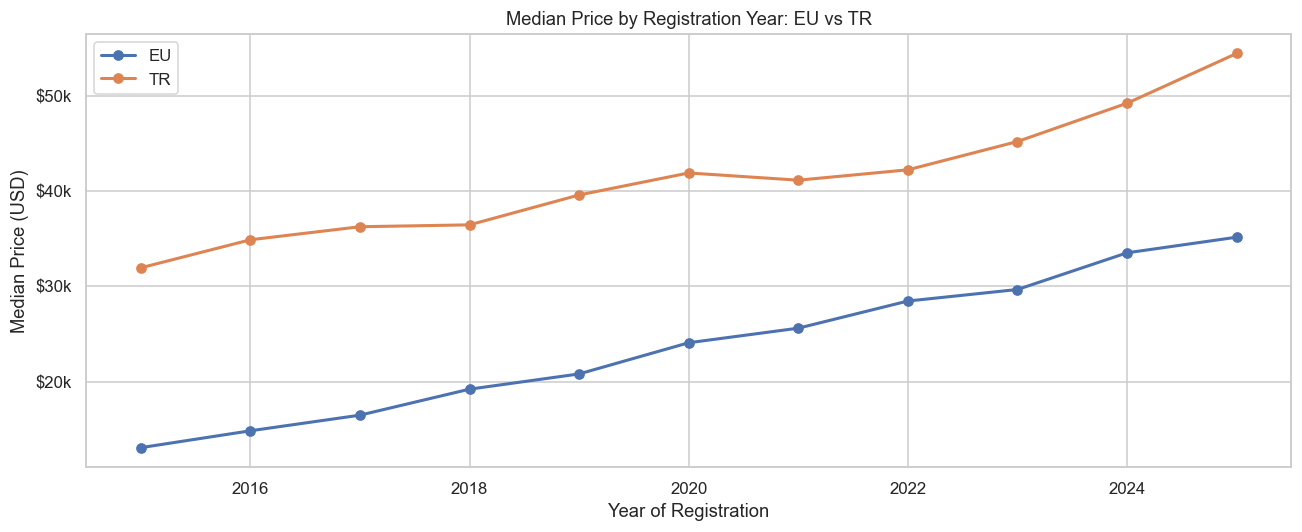

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

year_price = (
    combined[combined['price_usd'] < 90_000]
    .groupby(['market', 'year'])['price_usd']
    .median()
    .reset_index()
)

for market, color in [('EU', EU_COLOR), ('TR', TR_COLOR)]:
    sub = year_price[year_price['market'] == market]
    ax.plot(sub['year'].astype(int), sub['price_usd'],
            marker='o', label=market, color=color, lw=2)

ax.set_title('Median Price by Registration Year: EU vs TR')
ax.set_xlabel('Year of Registration')
ax.set_ylabel('Median Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fig_09_price_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

Price Trends by Registration Year: EU vs. TR

* Persistent Premium: Türkiye pazarındaki medyan fiyatlar, incelenen her bir tescil yılı için Avrupa'nın çok üzerindedir.

* The 2015 Benchmark: 2015 model araçlarda Türkiye'deki medyan fiyat ($31,954), Avrupa'nın ($13,078) 2.4 katından fazladır. Bu, eski araçlarda bile Türkiye pazarındaki değer koruma gücünün ne kadar yüksek olduğunu gösterir.

* Gap Narrowing for Newer Models: Yeni modellere (2024-2025) yaklaştıkça fiyat farkı oransal olarak bir miktar azalsa da, Türkiye hala dolar bazında en pahalı pazar olmaya devam ediyor.

* Inflationary Hedge: Her iki pazarda da yeni modellerde fiyat artışı görülmekle birlikte, Türkiye eğrisi daha yüksek bir tabandan başlayarak yükselmektedir.

## 19.Detailed Market Comparison: Turkey vs. Individual EU Countries

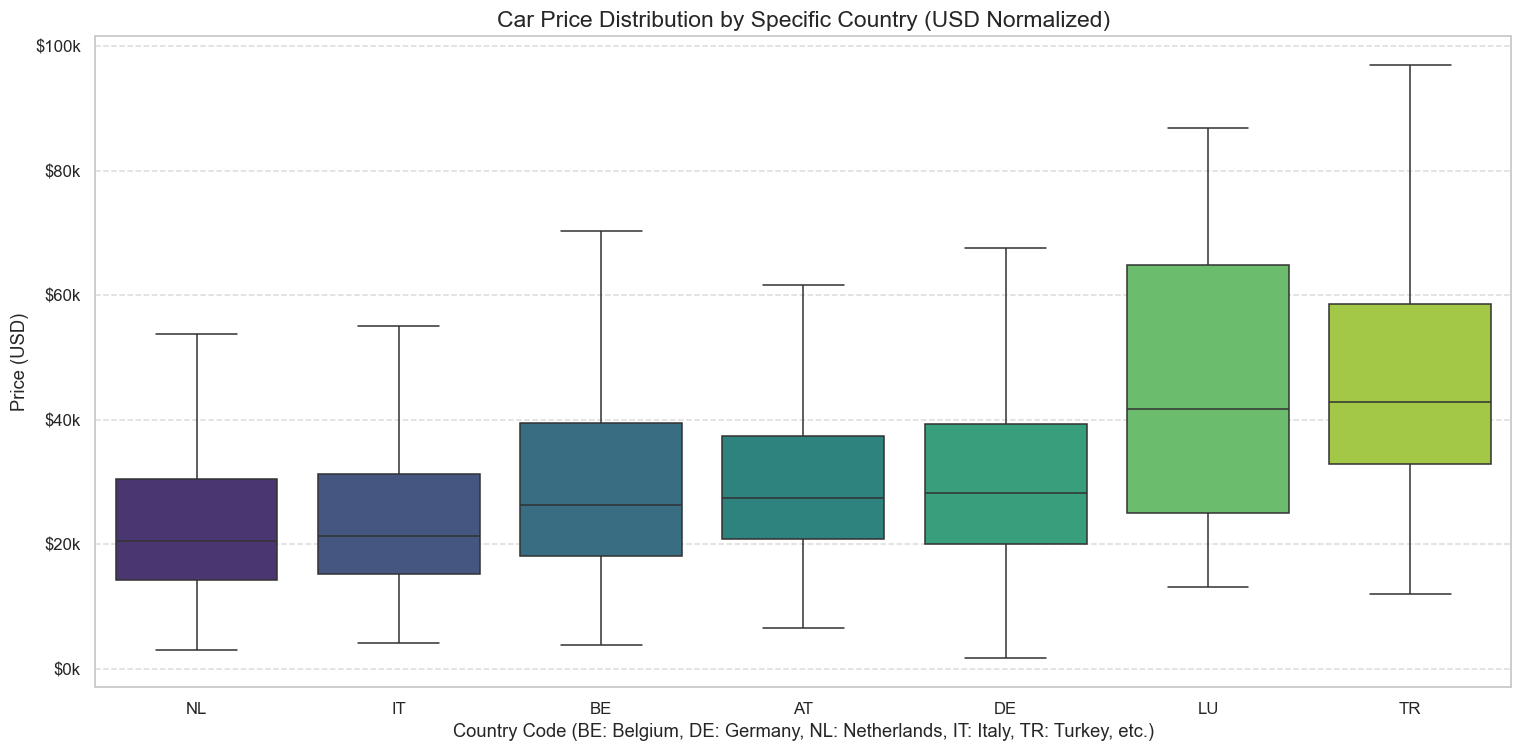

In [23]:
eu_data = pd.read_csv('../data/clean/eu_clean.csv')
tr_data = pd.read_csv('../data/clean/tr_clean.csv')

# Markaları standartlaştır ve birleştir
eu_data['brand'] = eu_data['brand'].str.upper().str.strip()
tr_data['brand'] = tr_data['brand'].str.upper().str.strip()

# Karşılaştırma için gerekli sütunları seç ve birleştir
cols = ['brand', 'price_usd', 'country']
combined_geo = pd.concat([eu_data[cols], tr_data[cols]], ignore_index=True)

#  Ülke bazlı sıralama (Medyan fiyata göre en ucuzdan en pahalıya)
country_rank = combined_geo.groupby('country')['price_usd'].median().sort_values().index

# Görselleştirme: Ülke Bazlı Fiyat Dağılımı (Boxplot)
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=combined_geo,
    x='country',
    y='price_usd',
    order=country_rank,
    palette='viridis',
    showfliers=False # Aykırı değerleri gizleyerek ana kutuları net görelim
)

plt.title('Car Price Distribution by Specific Country (USD Normalized)', fontsize=15)
plt.ylabel('Price (USD)')
plt.xlabel('Country Code (BE: Belgium, DE: Germany, NL: Netherlands, IT: Italy, TR: Turkey, etc.)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../outputs/fig_10_country_comparison_boxplot.png', dpi=150)
plt.show()

In [24]:
#  Özet Tablo: En popüler 5 marka için ülke bazlı fiyatlar
top_5_brands = ['VOLKSWAGEN', 'MERCEDES-BENZ', 'BMW', 'AUDI', 'FORD']
pivot_summary = (
    combined_geo[combined_geo['brand'].isin(top_5_brands)]
    .groupby(['country', 'brand'])['price_usd']
    .median()
    .unstack('brand')
)
print("Median Prices by Country and Brand (USD):")
print(pivot_summary.round(0).to_string())

Median Prices by Country and Brand (USD):
brand       AUDI      BMW     FORD  MERCEDES-BENZ  VOLKSWAGEN
country                                                      
AT       33132.0  32978.0  23419.0        38440.0     23067.0
BE       29645.0  33990.0  18698.0        33137.0     24959.0
DE       33979.0  39710.0  23870.0        39366.0     27390.0
IT       32588.0  31119.0  17490.0        33770.0     21989.0
LU       53889.0  80790.0      NaN        67089.0     29689.0
NL       29612.0  29204.0  14245.0        29912.0     17435.0
TR       79860.0  94776.0  42405.0        96723.0     51562.0


* The Ultimate Outlier (Turkey): Türkiye (TR), fiyat dağılımında tüm Avrupa ülkelerini açık ara geride bırakarak grafiğin en sağında (en pahalı) yer alıyor. Hatta Avrupa'nın en yüksek gelirli ülkelerinden biri olan Lüksemburg (LU) bile çoğu marka segmentinde Türkiye'nin gerisinde kalmıştır.

* Price Paradises (NL & IT): Hollanda (NL) ve İtalya (IT), ikinci el araç pazarında en erişilebilir ülkeler olarak öne çıkıyor. Örneğin, Hollanda'daki bir BMW'nin medyan fiyatı $29k iken, Türkiye'de aynı marka için bu değer $94k seviyelerine çıkmaktadır.

* Brand-Specific Gaps: * Premium Segment: Mercedes ve BMW gibi markalarda Türkiye ile Almanya (DE) arasındaki fiyat farkı 2.5 katına ulaşmaktadır.

* Volume Segment: Volkswagen ve Ford gibi daha geniş kitlelere hitap eden markalarda bile Türkiye, Avrupa ortalamasının 2 katı üzerindedir.

* Economic Reality: Grafik, Türkiye'deki vergi yükünün (ÖTV/KDV), pazar kısıtları ve bunun gibi faktörlerin, araç fiyatlarını Avrupa'daki "lüks" seviyelerin bile üzerine taşıdığını istatistiksel olarak kanıtlamaktadır.

## 20. Key Findings

In [25]:
print('=' * 52)
print('SUMMARY & INSIGHTS — P1 EDA')
print('=' * 52)

eu_med = eu['price_usd'].median()
tr_med = tr['price_usd'].median()

# --- Prices ---
print(f'\nMedian price (USD)')
print(f'  EU : ${eu_med:,.0f}')
print(f'  TR : ${tr_med:,.0f}')
print(f'  TR / EU ratio : {tr_med / eu_med:.2f}x')
print(f'\nDataset sizes : EU {len(eu):,}  ·  TR {len(tr):,}')

# --- Correlations ---
corr_km   = eu[['mileage', 'price_usd']].dropna().corr().iloc[0, 1]
corr_age  = eu[['age',     'price_usd']].dropna().corr().iloc[0, 1]
corr_hp   = eu[['hp',      'price_usd']].dropna().corr().iloc[0, 1]
tr_km_corr  = tr[['mileage', 'price_usd']].dropna().corr().iloc[0, 1]
tr_age_corr = tr[['age',     'price_usd']].dropna().corr().iloc[0, 1]

print(f'\nCorrelation with price_usd:')
print(f'  {"Feature":<12} {"EU":>6}  {"TR":>6}')
print(f'  {"Mileage":<12} {corr_km:>+.2f}  {tr_km_corr:>+.2f}')
print(f'  {"Age":<12} {corr_age:>+.2f}  {tr_age_corr:>+.2f}')
print(f'  {"HP":<12} {corr_hp:>+.2f}  {"N/A":>6}')

# --- Insight ---
print(f'\nKey Insight:')
print(f'  TR cars are {tr_med / eu_med:.2f}x more expensive than EU equivalents')
print(f'  in USD terms — driven by ÖTV (up to 220%) and import restrictions.')
print(f'  HP is the strongest price predictor in EU (r={corr_hp:+.2f}),')
print(f'  while mileage and age show similar moderate effects in both markets.')

SUMMARY & INSIGHTS — P1 EDA

Median price (USD)
  EU : $25,845
  TR : $42,900
  TR / EU ratio : 1.66x

Dataset sizes : EU 7,155  ·  TR 4,421

Correlation with price_usd:
  Feature          EU      TR
  Mileage      -0.33  -0.28
  Age          -0.40  -0.32
  HP           +0.75     N/A

Key Insight:
  TR cars are 1.66x more expensive than EU equivalents
  in USD terms — driven by ÖTV (up to 220%) and import restrictions.
  HP is the strongest price predictor in EU (r=+0.75),
  while mileage and age show similar moderate effects in both markets.
